PART B : REGULARIZATION TECHNIQUES

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2

STEP 1: LOADING PNEUMONIAMNIST DATASET

Original Train Shape : (4708, 28, 28)
Original Val Shape   : (524, 28, 28)
Original Test Shape  : (624, 28, 28)

STEP 2: PREPROCESSING AND SPLITTING

Total Samples : 5856
Input Features: 1024

PneumoniaMNIST Split:
Training   : (4684, 1024)
Validation : (586, 1024)
Testing    : (586, 1024)

STEP 3: EXPLORATORY DATA ANALYSIS

Class-wise Distribution:
Class 0 (Normal): 1583
Class 1 (Pneumonia): 4273


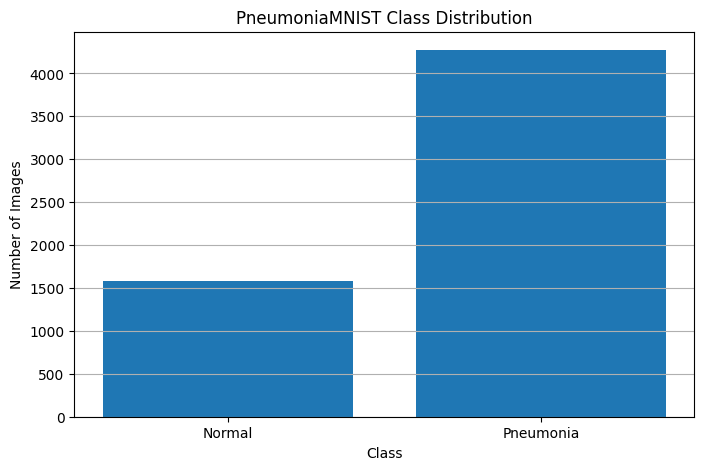

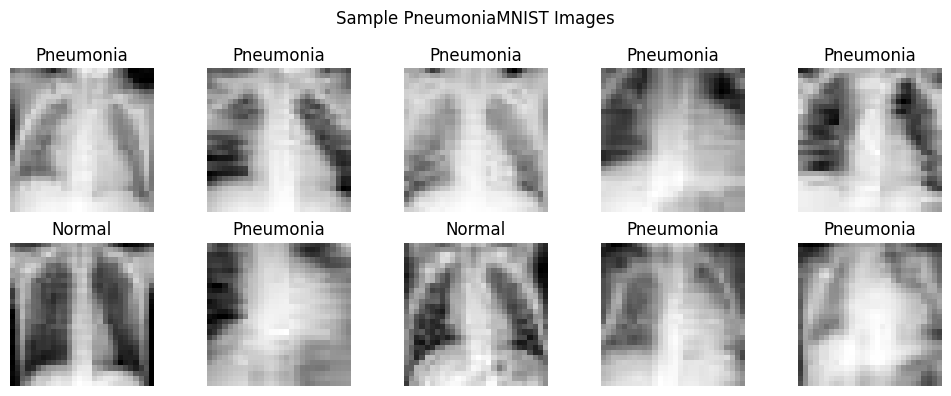



RUNNING PART B FOR PNEUMONIAMNIST


COMMON MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,202 (1.16 MB)

 Trainable params: 304,202 (1.16 MB)

 Non-trainable params: 0 (0.00 B)



REGULARIZATION EXPERIMENT : PneumoniaMNIST


----------------------------------------------------------------------
TECHNIQUE : Baseline
----------------------------------------------------------------------
Epoch 8: early stopping
Restoring model weights from the end of the best epoch: 6.

Accuracy : 93.86 %
Precision : 0.9381
Recall : 0.9386
F1 Score : 0.9382
Actual Epochs Run : 8
Early Stopping Patience : 2
Learning Rate : 0.001
Hidden Layer 1 : 256 - ReLU
Hidden Layer 2 : 128 - ReLU
Hidden Layer 3 : 64 - ReLU
Output Layer : 10 - Softmax
Time : 7.92 seconds

Confusion Matrix:
[[137  21]
 [ 15 413]]


----------------------------------------------------------------------
TECHNIQUE : L1
----------------------------------------------------------------------
Restoring model weights from the end of the best epoch: 9.

Accuracy : 93.86 %
Precision : 0.9381
Recall : 0.9386
F1 Score : 0.9376
Actual Epochs Run : 10
Early Stopping Patience : 2
Learning Rate : 0.001
Hidden Layer 1 : 256 - Re

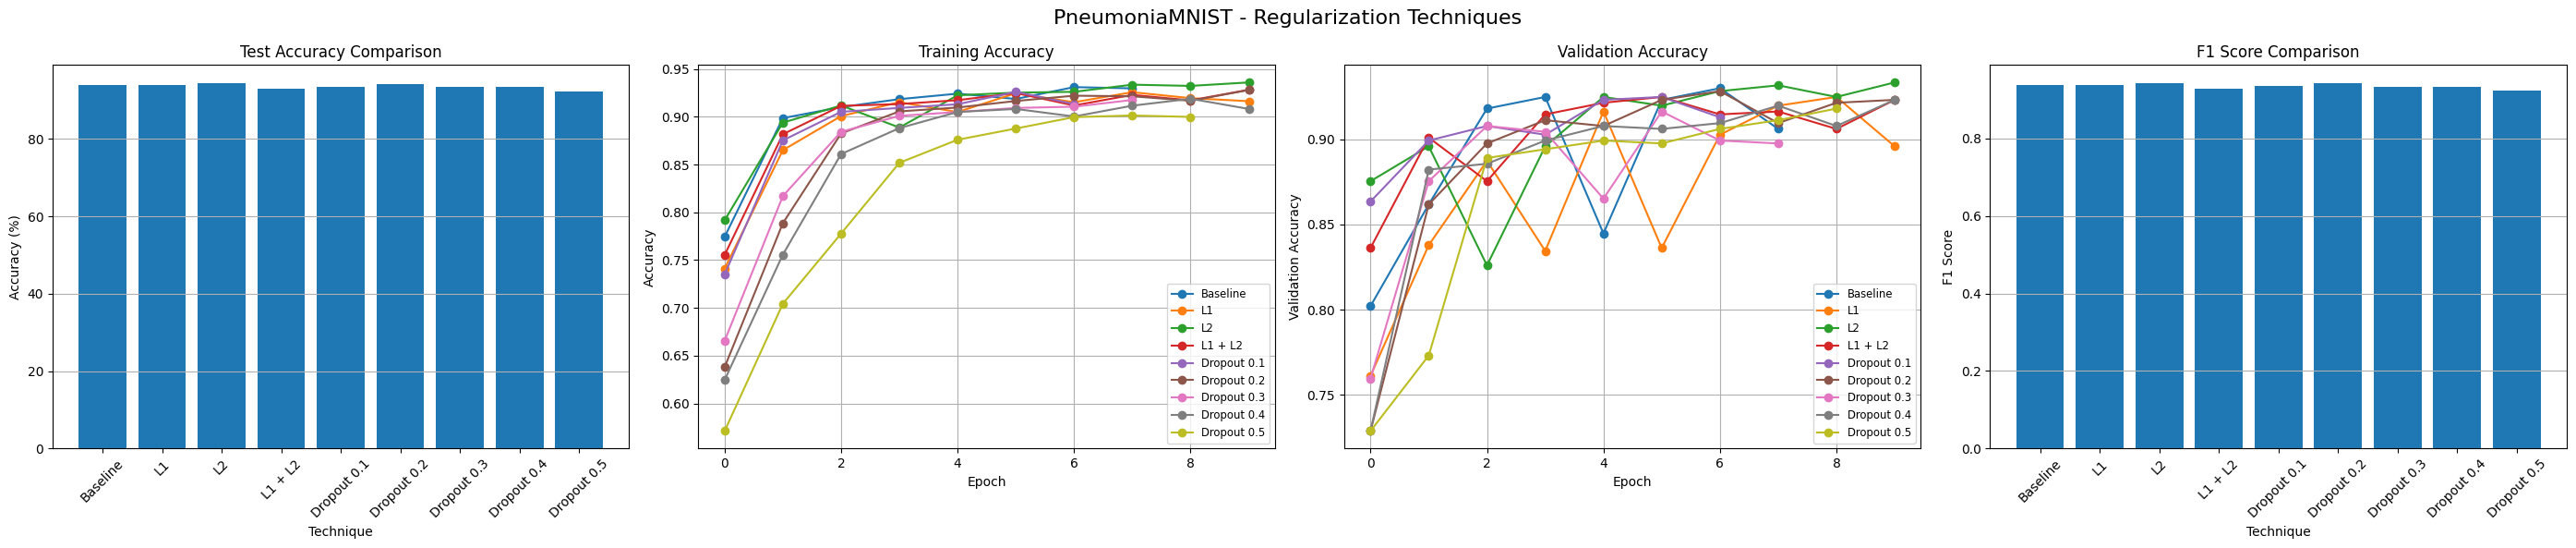



PNEUMONIAMNIST CONFUSION MATRICES


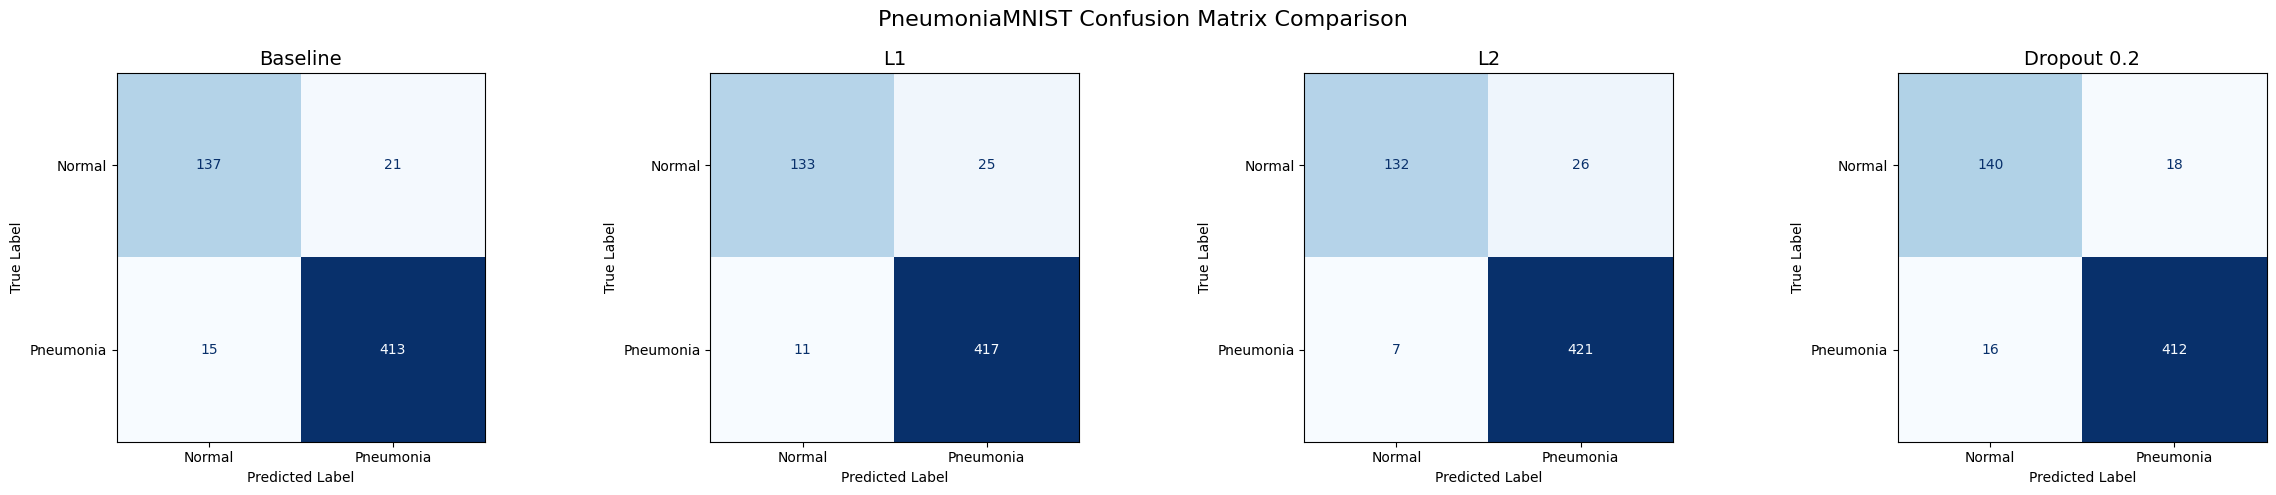



FINAL PART B COMPARISON

PneumoniaMNIST Results:
  Technique Regularizer Type  Dropout Rate  Learning Rate  Patience (ES) H1 Activation H2 Activation H3 Activation Output Activation  Accuracy (%)  Precision  Recall  F1 Score  Actual Epochs Run  Time (sec)
   Baseline             None           0.0          0.001              2          ReLU          ReLU          ReLU           Softmax         93.86     0.9381  0.9386    0.9382                  8        7.92
         L1               L1           0.0          0.001              2          ReLU          ReLU          ReLU           Softmax         93.86     0.9381  0.9386    0.9376                 10        6.20
         L2               L2           0.0          0.001              2          ReLU          ReLU          ReLU           Softmax         94.37     0.9439  0.9437    0.9425                 10        8.20
    L1 + L2          L1 + L2           0.0          0.001              2          ReLU          ReLU          ReLU       

In [ ]:
# ============================================================
# EXPERIMENT:
# IMPLEMENTATION OF REGULARIZATION TECHNIQUES
# L1, L2, L1+L2, DROPOUT, EARLY STOPPING
# Dataset: PneumoniaMNIST
# Architecture: 1024 - 256 - 128 - 64 - 10
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1, l2, l1_l2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================================
# MEDMNIST IMPORT
# ============================================================

try:
    import medmnist
    from medmnist import PneumoniaMNIST

except ModuleNotFoundError:

    import sys
    import subprocess

    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "medmnist"]
    )

    import medmnist
    from medmnist import PneumoniaMNIST


print("=" * 80)
print("PART B : REGULARIZATION TECHNIQUES")
print("=" * 80)

print("\nTensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)


# ============================================================
# STEP 1: LOAD PNEUMONIAMNIST
# ============================================================

print("\n" + "=" * 80)
print("STEP 1: LOADING PNEUMONIAMNIST DATASET")
print("=" * 80)

train_med = PneumoniaMNIST(
    split="train",
    download=True
)

val_med = PneumoniaMNIST(
    split="val",
    download=True
)

test_med = PneumoniaMNIST(
    split="test",
    download=True
)

X_train_med = train_med.imgs
y_train_med = train_med.labels

X_val_med = val_med.imgs
y_val_med = val_med.labels

X_test_med = test_med.imgs
y_test_med = test_med.labels

print("\nOriginal Train Shape :", X_train_med.shape)
print("Original Val Shape   :", X_val_med.shape)
print("Original Test Shape  :", X_test_med.shape)


# ============================================================
# STEP 2: COMBINE DATASET
# ============================================================

print("\n" + "=" * 80)
print("STEP 2: PREPROCESSING AND SPLITTING")
print("=" * 80)

X_med = np.concatenate(
    [X_train_med, X_val_med, X_test_med],
    axis=0
)

y_med = np.concatenate(
    [y_train_med, y_val_med, y_test_med],
    axis=0
)

# Flatten 28 x 28 = 784
X_med = X_med.reshape(
    X_med.shape[0],
    -1
).astype("float32")

# Normalize
X_med = X_med / 255.0


# ============================================================
# CONVERT 784 INPUT FEATURES TO 1024
# ============================================================

X_med = np.pad(
    X_med,
    ((0, 0), (0, 240)),
    mode="constant"
)

# Convert labels to 1-D
y_med = y_med.reshape(-1).astype("int32")

print("\nTotal Samples :", X_med.shape[0])
print("Input Features:", X_med.shape[1])


# ============================================================
# 80% TRAIN - 10% VALIDATION - 10% TEST
# ============================================================

xtr_med, xtemp_med, ytr_med, ytemp_med = train_test_split(
    X_med,
    y_med,
    test_size=0.20,
    random_state=42,
    stratify=y_med
)

xval_med, xte_med, yval_med, yte_med = train_test_split(
    xtemp_med,
    ytemp_med,
    test_size=0.50,
    random_state=42,
    stratify=ytemp_med
)

print("\nPneumoniaMNIST Split:")
print("Training   :", xtr_med.shape)
print("Validation :", xval_med.shape)
print("Testing    :", xte_med.shape)


# ============================================================
# STEP 3: EXPLORATORY DATA ANALYSIS
# ============================================================

print("\n" + "=" * 80)
print("STEP 3: EXPLORATORY DATA ANALYSIS")
print("=" * 80)

class_labels_med = {
    0: "Normal",
    1: "Pneumonia"
}

class_distribution = pd.Series(
    y_med
).value_counts().sort_index()

print("\nClass-wise Distribution:")

for i in class_distribution.index:

    print(
        "Class",
        i,
        "(" + class_labels_med[i] + "):",
        class_distribution[i]
    )


# ============================================================
# CLASS DISTRIBUTION GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    class_distribution.index,
    class_distribution.values
)

plt.title(
    "PneumoniaMNIST Class Distribution"
)

plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(
    [0, 1],
    ["Normal", "Pneumonia"]
)

plt.grid(axis="y")

plt.show()


# ============================================================
# SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(10, 4))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_med[i][:784].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        class_labels_med[y_med[i]]
    )

    plt.axis("off")

plt.suptitle(
    "Sample PneumoniaMNIST Images"
)

plt.tight_layout()

plt.show()


# ============================================================
# FUNCTION 1: BUILD MODEL
# ============================================================

def build_regularized_model(
    input_size,
    regularizer=None,
    dropout_rate=0.0
):

    model = Sequential([

        # INPUT
        Input(
            shape=(input_size,)
        ),

        # HIDDEN LAYER 1
        Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizer
        ),

        Dropout(
            dropout_rate
        ),

        # HIDDEN LAYER 2
        Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizer
        ),

        Dropout(
            dropout_rate
        ),

        # HIDDEN LAYER 3
        Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizer
        ),

        Dropout(
            dropout_rate
        ),

        # OUTPUT LAYER
        Dense(
            10,
            activation="softmax"
        )
    ])

    return model


# ============================================================
# CONVERT LABELS TO 10 OUTPUT FORMAT
# ============================================================

def convert_labels_10_class(labels):

    converted = np.zeros(
        (len(labels), 10),
        dtype="float32"
    )

    for i, label in enumerate(labels):

        converted[
            i,
            int(label)
        ] = 1.0

    return converted


ytr_med_10 = convert_labels_10_class(
    ytr_med
)

yval_med_10 = convert_labels_10_class(
    yval_med
)

yte_med_10 = convert_labels_10_class(
    yte_med
)


# ============================================================
# FUNCTION 2: REGULARIZATION EXPERIMENT
# ============================================================

def run_regularization_exp(
    xtr,
    ytr,
    xval,
    yval,
    xte,
    yte,
    dataset_name
):

    print("\n")

    print("=" * 80)

    print(
        "REGULARIZATION EXPERIMENT :",
        dataset_name
    )

    print("=" * 80)

    results = []
    histories = {}
    models = {}
    confusion_matrices = {}


    # ========================================================
    # REGULARIZATION TECHNIQUES
    # ========================================================

    techniques = [

        (
            "Baseline",
            None,
            0.0
        ),

        (
            "L1",
            l1(0.001),
            0.0
        ),

        (
            "L2",
            l2(0.001),
            0.0
        ),

        (
            "L1 + L2",
            l1_l2(
                l1=0.0005,
                l2=0.0005
            ),
            0.0
        )
    ]


    # ========================================================
    # DROPOUT TECHNIQUES
    # ========================================================

    dropout_techniques = []

    for dropout_value in [
        0.1,
        0.2,
        0.3,
        0.4,
        0.5
    ]:

        dropout_techniques.append(
            (
                "Dropout " + str(dropout_value),
                None,
                dropout_value
            )
        )


    all_techniques = (
        techniques +
        dropout_techniques
    )


    # ========================================================
    # BEST DROPOUT
    # ========================================================

    best_dropout_accuracy = -1

    best_dropout_technique = None


    # ========================================================
    # RUN EACH TECHNIQUE
    # ========================================================

    for technique, regularizer, dropout_rate in all_techniques:

        print("\n")

        print("-" * 70)

        print(
            "TECHNIQUE :",
            technique
        )

        print("-" * 70)


        # Build model
        model = build_regularized_model(

            input_size=xtr.shape[1],

            regularizer=regularizer,

            dropout_rate=dropout_rate
        )


        # Compile
        model.compile(

            optimizer=Adam(
                learning_rate=0.001
            ),

            loss="categorical_crossentropy",

            metrics=["accuracy"]
        )


        # ====================================================
        # EARLY STOPPING
        # ====================================================

        early_stopping = EarlyStopping(

            monitor="val_loss",

            patience=2,

            restore_best_weights=True,

            verbose=1
        )


        # ====================================================
        # TRAIN
        # ====================================================

        start_time = time.time()

        history = model.fit(

            xtr,

            ytr,

            validation_data=(
                xval,
                yval
            ),

            epochs=10,

            batch_size=128,

            callbacks=[
                early_stopping
            ],

            verbose=0
        )

        total_time = (
            time.time() -
            start_time
        )


        # ====================================================
        # PREDICTION
        # ====================================================

        probabilities = model.predict(
            xte,
            verbose=0
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        actual = np.argmax(
            yte,
            axis=1
        )


        # ====================================================
        # METRICS
        # ====================================================

        accuracy = accuracy_score(
            actual,
            predictions
        )

        precision = precision_score(
            actual,
            predictions,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            actual,
            predictions,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            actual,
            predictions,
            average="weighted",
            zero_division=0
        )


        # ====================================================
        # 2 x 2 CONFUSION MATRIX
        # ====================================================

        # Convert predictions to binary:
        # 0 = Normal
        # 1 = Pneumonia

        actual_binary = (
            actual > 0
        ).astype(int)

        prediction_binary = (
            predictions > 0
        ).astype(int)

        cm = confusion_matrix(
            actual_binary,
            prediction_binary,
            labels=[0, 1]
        )

        confusion_matrices[
            technique
        ] = cm


        # ====================================================
        # REGULARIZER NAME
        # ====================================================

        if technique == "Baseline":

            reg_type = "None"

        elif technique == "L1":

            reg_type = "L1"

        elif technique == "L2":

            reg_type = "L2"

        elif technique == "L1 + L2":

            reg_type = "L1 + L2"

        else:

            reg_type = "None"


        # ====================================================
        # PRINT RESULTS
        # ====================================================

        print(
            "\nAccuracy :",
            round(
                accuracy * 100,
                2
            ),
            "%"
        )

        print(
            "Precision :",
            round(
                precision,
                4
            )
        )

        print(
            "Recall :",
            round(
                recall,
                4
            )
        )

        print(
            "F1 Score :",
            round(
                f1,
                4
            )
        )

        print(
            "Actual Epochs Run :",
            len(
                history.history["loss"]
            )
        )

        print(
            "Early Stopping Patience :",
            early_stopping.patience
        )

        print(
            "Learning Rate :",
            0.001
        )

        print(
            "Hidden Layer 1 : 256 - ReLU"
        )

        print(
            "Hidden Layer 2 : 128 - ReLU"
        )

        print(
            "Hidden Layer 3 : 64 - ReLU"
        )

        print(
            "Output Layer : 10 - Softmax"
        )

        print(
            "Time :",
            round(
                total_time,
                2
            ),
            "seconds"
        )

        print(
            "\nConfusion Matrix:"
        )

        print(cm)


        # ====================================================
        # STORE RESULTS
        # ====================================================

        results.append({

            "Technique":
                technique,

            "Regularizer Type":
                reg_type,

            "Dropout Rate":
                dropout_rate,

            "Learning Rate":
                0.001,

            "Patience (ES)":
                early_stopping.patience,

            "H1 Activation":
                "ReLU",

            "H2 Activation":
                "ReLU",

            "H3 Activation":
                "ReLU",

            "Output Activation":
                "Softmax",

            "Accuracy (%)":
                round(
                    accuracy * 100,
                    2
                ),

            "Precision":
                round(
                    precision,
                    4
                ),

            "Recall":
                round(
                    recall,
                    4
                ),

            "F1 Score":
                round(
                    f1,
                    4
                ),

            "Actual Epochs Run":
                len(
                    history.history["loss"]
                ),

            "Time (sec)":
                round(
                    total_time,
                    2
                )
        })


        # ====================================================
        # BEST DROPOUT
        # ====================================================

        if technique.startswith("Dropout"):

            if accuracy > best_dropout_accuracy:

                best_dropout_accuracy = accuracy

                best_dropout_technique = technique


        histories[
            technique
        ] = history

        models[
            technique
        ] = model


    # ========================================================
    # RESULT TABLE
    # ========================================================

    result_table = pd.DataFrame(
        results
    )

    return (
        result_table,
        histories,
        models,
        confusion_matrices,
        best_dropout_technique
    )


# ============================================================
# PART B - PNEUMONIAMNIST
# ============================================================

# ============================================================
# PART B - PNEUMONIAMNIST
# ============================================================

print("\n")

print("=" * 80)

print(
    "RUNNING PART B FOR PNEUMONIAMNIST"
)

print("=" * 80)


# ============================================================
# COMMON MODEL ARCHITECTURE - DISPLAY ONLY ONCE
# ============================================================

print("\n")

print("=" * 80)

print(
    "COMMON MODEL ARCHITECTURE"
)

print("=" * 80)


architecture_model = build_regularized_model(

    input_size=xtr_med.shape[1],

    regularizer=None,

    dropout_rate=0.0
)


architecture_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)


architecture_model.summary()


(
    reg_result_med,
    reg_hist_med,
    reg_models_med,
    cm_med,
    best_med_dropout_technique
) = run_regularization_exp(

    xtr_med,
    ytr_med_10,

    xval_med,
    yval_med_10,

    xte_med,
    yte_med_10,

    dataset_name="PneumoniaMNIST"
)


# ============================================================
# RESULT TABLE
# ============================================================

print("\n")

print("=" * 80)

print(
    "PNEUMONIAMNIST REGULARIZATION RESULTS"
)

print("=" * 80)

print(
    reg_result_med.to_string(
        index=False
    )
)


# ============================================================
# ALL 4 GRAPHS IN ONE ROW
# ============================================================

fig, axes = plt.subplots(
    1,
    4,
    figsize=(28, 6)
)


# ============================================================
# GRAPH 1: TEST ACCURACY
# ============================================================

axes[0].bar(
    reg_result_med["Technique"],
    reg_result_med["Accuracy (%)"]
)

axes[0].set_title(
    "Test Accuracy Comparison"
)

axes[0].set_xlabel(
    "Technique"
)

axes[0].set_ylabel(
    "Accuracy (%)"
)

axes[0].tick_params(
    axis="x",
    rotation=45
)

axes[0].grid(
    axis="y"
)


# ============================================================
# GRAPH 2: TRAINING ACCURACY
# ============================================================

for technique in reg_hist_med:

    axes[1].plot(
        reg_hist_med[technique].history["accuracy"],
        marker="o",
        label=technique
    )

axes[1].set_title(
    "Training Accuracy"
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "Accuracy"
)

axes[1].legend(
    fontsize="small"
)

axes[1].grid(True)


# ============================================================
# GRAPH 3: VALIDATION ACCURACY
# ============================================================

for technique in reg_hist_med:

    axes[2].plot(
        reg_hist_med[technique].history["val_accuracy"],
        marker="o",
        label=technique
    )

axes[2].set_title(
    "Validation Accuracy"
)

axes[2].set_xlabel(
    "Epoch"
)

axes[2].set_ylabel(
    "Validation Accuracy"
)

axes[2].legend(
    fontsize="small"
)

axes[2].grid(True)


# ============================================================
# GRAPH 4: F1 SCORE
# ============================================================

axes[3].bar(
    reg_result_med["Technique"],
    reg_result_med["F1 Score"]
)

axes[3].set_title(
    "F1 Score Comparison"
)

axes[3].set_xlabel(
    "Technique"
)

axes[3].set_ylabel(
    "F1 Score"
)

axes[3].tick_params(
    axis="x",
    rotation=45
)

axes[3].grid(
    axis="y"
)


# ============================================================
# DISPLAY ALL GRAPHS IN ONE ROW
# ============================================================

plt.suptitle(
    "PneumoniaMNIST - Regularization Techniques",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# CONFUSION MATRICES
# ============================================================

print("\n")

print("=" * 80)

print(
    "PNEUMONIAMNIST CONFUSION MATRICES"
)

print("=" * 80)


cm_display_keys = [
    "Baseline",
    "L1",
    "L2"
]

if best_med_dropout_technique is not None:

    cm_display_keys.append(
        best_med_dropout_technique
    )


# ============================================================
# DISPLAY 2 x 2 CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(
    1,
    len(cm_display_keys),
    figsize=(
        6 * len(cm_display_keys),
        5
    )
)

if len(cm_display_keys) == 1:

    axes = [axes]


for i, technique in enumerate(
    cm_display_keys
):

    if technique in cm_med:

        disp = ConfusionMatrixDisplay(

            confusion_matrix=cm_med[
                technique
            ],

            display_labels=[
                "Normal",
                "Pneumonia"
            ]
        )

        disp.plot(
            ax=axes[i],
            cmap="Blues",
            values_format="d",
            colorbar=False
        )

        axes[i].set_title(
            technique,
            fontsize=14
        )

        axes[i].set_xlabel(
            "Predicted Label"
        )

        axes[i].set_ylabel(
            "True Label"
        )

        axes[i].grid(False)


plt.suptitle(
    "PneumoniaMNIST Confusion Matrix Comparison",
    fontsize=16
)

plt.tight_layout()

plt.show()


# ============================================================
# FINAL COMPARISON
# ============================================================

print("\n")

print("=" * 80)

print(
    "FINAL PART B COMPARISON"
)

print("=" * 80)

print(
    "\nPneumoniaMNIST Results:"
)

print(
    reg_result_med.to_string(
        index=False
    )
)


# ============================================================
# FIND BEST TECHNIQUE
# ============================================================

best_index = reg_result_med[
    "Accuracy (%)"
].idxmax()

best_technique = reg_result_med.loc[
    best_index,
    "Technique"
]

best_accuracy = reg_result_med.loc[
    best_index,
    "Accuracy (%)"
]


print(
    "\nBest Technique :",
    best_technique
)

print(
    "Best Accuracy :",
    best_accuracy,
    "%"
)


print("\n")

print("=" * 80)

print(
    "PART B COMPLETED SUCCESSFULLY"
)

print("=" * 80)